In [1]:
# ══════════════════════════════════════════════════════════════════════
# RECOMMENDED COMPUTE — evaluation (in-process RF+XGB+MLP+ISO, plots, t-SNE)
#   >>> cpu-8c-std   (8 cores, 64 GB RAM, ~RM4.49/hr)   <-- pick this (RF is CAPPED)
#   Why: every model now loads in ONE process. A capped RF (~10-20 GB) + XGB
#        + MLP + the test set fit in 64 GB. Predict/plots/t-SNE are CPU work.
#   If RF is max_depth=None: use cpu-16c-mem (256 GB) - the unbounded forest
#        alone needs ~100 GB when deserialised.
# ══════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────
# SETUP — Portable project root (RUN THIS CELL FIRST)
#
# Sets the working directory to the ML-IDS project root so every relative
# path in this notebook resolves regardless of where Jupyter was launched.
# Override by exporting ML_IDS_ROOT=/path/to/ML-IDS before starting Jupyter.
# ──────────────────────────────────────────────────────────────────
import os
from pathlib import Path

def _find_project_root():
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / 'data').is_dir() and (cand / 'notebooks').is_dir():
            return cand
    return Path.cwd()

os.chdir(os.environ.get('ML_IDS_ROOT') or _find_project_root())
print('Project root:', os.getcwd())

Project root: /home/user/22056253/ML-IDS


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 0 — Setup: imports, paths, data loading, and shared utilities
#
# Loads the full 56-feature hybrid test set (40 MI-selected + 16 autoencoder
# latent features) fully into RAM.
#
# predict_calibrated() applies per-class probability thresholds that were
# grid-searched on the validation set during training. It picks the
# highest-probability class that exceeds its threshold; if no class
# qualifies it falls back to argmax. This improves minority-class F1
# compared to plain argmax.
# ─────────────────────────────────────────────────────────────────────
import os
# KMP_DUPLICATE_LIB_OK guards against the libiomp5-vs-libomp abort that fires
# when torch (MKL/iomp) and XGBoost (libomp) are imported into the SAME kernel
# — which they now are, since every model runs in-process below. This is a
# crash guard only; it does NOT throttle threads, so the CPU runs full-width.
# Must be set before importing torch. Takes effect only on a FRESH kernel.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import joblib
import torch
import torch.nn as nn

MODELS  = 'models'
RESULTS = 'results'
os.makedirs(RESULTS, exist_ok=True)

X_test = np.load('data/features/X_test_hybrid.npy')
y_test = np.load('data/processed/y_test.npy')
le     = joblib.load(f'{MODELS}/label_encoder.pkl')

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)

def predict_calibrated(proba, thresholds):
    masked = np.where(proba >= thresholds, proba, -1.0)
    no_qualify = np.all(masked < 0, axis=1)
    result = np.argmax(masked, axis=1)
    result[no_qualify] = np.argmax(proba[no_qualify], axis=1)
    return result

print(f'X_test : {X_test.shape}')
print(f'Device : {device}')
print(f'Classes: {list(le.classes_)}')

X_test : (2434942, 56)
Device : cpu
Classes: ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce']


In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — MLP inference with calibrated thresholds
#
# Rebuilds the exact MLP architecture used during training
# (512 → 256 → 128 → 15 classes) and loads the saved weights.
# Inference runs in a single forward pass on the device.
# Softmax converts raw logits to per-class probabilities before
# calibrated thresholds are applied.
# Raw probabilities are kept in memory (proba_mlp) and saved to disk for
# the ensemble and calibration cells.
# ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.network(x)

print('Loading MLP...')
mlp = MLP(X_test.shape[1], len(le.classes_)).to(device)
mlp.load_state_dict(torch.load(f'{MODELS}/mlp.pth', weights_only=True))
mlp.eval()

X_test_t = torch.from_numpy(X_test.astype(np.float32, copy=False)).to(device)
with torch.no_grad():
    proba_mlp = torch.softmax(mlp(X_test_t), dim=1).cpu().numpy()

thresholds = np.load(f'{MODELS}/thresholds_mlp.npy')
y_pred_mlp = predict_calibrated(proba_mlp, thresholds)
np.save(f'{RESULTS}/y_pred_mlp.npy',  y_pred_mlp)
np.save(f'{RESULTS}/proba_mlp.npy',   proba_mlp)
print('MLP done.')

Loading MLP...
MLP done.


In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Random Forest inference (in-process)
#
# Loads the Random Forest and predicts on the full test set in this kernel.
# Saves calibrated predictions, raw probabilities, and feature importances
# to results/ so the plotting/ensemble/calibration cells can reload them
# after a kernel restart (re-run Cells 0 and 5 only in that case).
# ─────────────────────────────────────────────────────────────────────
print('Loading Random Forest...')
rf             = joblib.load(f'{MODELS}/random_forest.pkl')
thresholds_rf  = np.load(f'{MODELS}/thresholds_rf.npy')

print('Predicting...')
proba_rf       = rf.predict_proba(X_test)
y_pred_rf      = predict_calibrated(proba_rf, thresholds_rf)
importances_rf = rf.feature_importances_.copy()

np.save(f'{RESULTS}/y_pred_rf.npy',      y_pred_rf)
np.save(f'{RESULTS}/proba_rf.npy',       proba_rf)
np.save(f'{RESULTS}/importances_rf.npy', importances_rf)
print('RF done — y_pred_rf, proba_rf, importances_rf saved.')

Loading Random Forest...
Predicting...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.6s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:   17.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:   27.9s finished


RF done — y_pred_rf, proba_rf, importances_rf saved.


In [5]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — XGBoost inference (in-process)
#
# Loads XGBoost and predicts on the full test set in a single call.
# Saves calibrated predictions and raw probabilities to results/.
# ─────────────────────────────────────────────────────────────────────
import xgboost as xgb
print('Loading XGBoost...')
xgb_model      = joblib.load(f'{MODELS}/xgboost.pkl')
thresholds_xgb = np.load(f'{MODELS}/thresholds_xgb.npy')

print('Predicting...')
proba_xgb  = xgb_model.predict_proba(X_test)
y_pred_xgb = predict_calibrated(proba_xgb, thresholds_xgb)

np.save(f'{RESULTS}/y_pred_xgb.npy', y_pred_xgb)
np.save(f'{RESULTS}/proba_xgb.npy',  proba_xgb)
print('XGBoost done — y_pred_xgb, proba_xgb saved.')

Loading XGBoost...


/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [23:50:31] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [23:50:31] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [23:50:31] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


Predicting...


XGBoost done — y_pred_xgb, proba_xgb saved.


In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Isolation Forest inference (in-process)
#
# The Isolation Forest was trained on benign-only traffic to learn the
# normal-behaviour distribution, then applied to the full test set.
# Samples that deviate from the benign distribution are flagged as
# anomalies (label = -1 → converted to 1 in anomaly_flags).
# ─────────────────────────────────────────────────────────────────────
print('Loading Isolation Forest...')
iso_forest    = joblib.load(f'{MODELS}/isolation_forest.pkl')
anomaly_flags = (iso_forest.predict(X_test) == -1).astype(int)
np.save(f'{RESULTS}/anomaly_flags.npy', anomaly_flags)
print('Isolation Forest done — anomaly_flags saved.')

Loading Isolation Forest...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.8s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s


Isolation Forest done — anomaly_flags saved.


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — (Re)load predictions and probabilities from disk
#
# Cells 1-4 already hold these arrays in memory; this cell reloads them
# from results/ so the notebook can also be resumed after a kernel restart
# by running only Cells 0 and 5 (the prediction files are already on disk).
#
# NOTE: anomaly_flags_ae.npy is NOT generated by this notebook.
# It is produced by model_training.ipynb Cell 12 (AE threshold
# calibration and test-set evaluation). Run model_training.ipynb in
# full before running this notebook.
# ─────────────────────────────────────────────────────────────────────
y_pred_rf        = np.load(f'{RESULTS}/y_pred_rf.npy')
y_pred_xgb       = np.load(f'{RESULTS}/y_pred_xgb.npy')
y_pred_mlp       = np.load(f'{RESULTS}/y_pred_mlp.npy')
anomaly_flags    = np.load(f'{RESULTS}/anomaly_flags.npy')
anomaly_flags_ae = np.load(f'{RESULTS}/anomaly_flags_ae.npy')
importances_rf   = np.load(f'{RESULTS}/importances_rf.npy')

# Raw probability arrays — needed by ensemble and calibration cells.
try:
    proba_rf  = np.load(f'{RESULTS}/proba_rf.npy')
    proba_xgb = np.load(f'{RESULTS}/proba_xgb.npy')
    proba_mlp = np.load(f'{RESULTS}/proba_mlp.npy')
    print('Probability arrays loaded (needed for ensemble and calibration cells).')
except FileNotFoundError as e:
    print(f'WARNING: {os.path.basename(e.filename)} not found.')
    print('Re-run Cells 1, 2, 3 to generate probability files for ensemble/calibration.')
    proba_rf = proba_xgb = proba_mlp = None

results = {}
print('All predictions loaded from disk.')

Probability arrays loaded (needed for ensemble and calibration cells).
All predictions loaded from disk.


In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 — Per-class classification reports (precision / recall / F1)
#
# Prints a full sklearn classification_report for each supervised model.
# All predictions use the per-class calibrated thresholds computed during
# training, so these numbers reflect the best the trained models can do.
# zero_division=0 silences warnings for classes with no positive
# predictions (relevant for tiny classes like SQL Injection: 13 samples).
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf,
      target_names=le.classes_, zero_division=0))

print("=" * 60)
print("XGBOOST")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb,
      target_names=le.classes_, zero_division=0))

print("=" * 60)
print("MLP")
print("=" * 60)
print(classification_report(y_test, y_pred_mlp,
      target_names=le.classes_, zero_division=0))

RANDOM FOREST
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99   2022707
                     Bot       0.99      1.00      0.99     42929
        Brute Force -Web       0.71      0.67      0.69        91
        Brute Force -XSS       0.69      0.74      0.71        34
        DDOS attack-HOIC       1.00      1.00      1.00    102902
    DDOS attack-LOIC-UDP       0.76      0.98      0.86       259
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     86429
   DoS attacks-GoldenEye       1.00      1.00      1.00      6226
        DoS attacks-Hulk       1.00      1.00      1.00     69287
DoS attacks-SlowHTTPTest       0.76      0.52      0.62     20984
   DoS attacks-Slowloris       0.90      0.99      0.94      1648
          FTP-BruteForce       0.72      0.88      0.79     29004
           Infilteration       0.33      0.24      0.28     24290
           SQL Injection       0.73      0.62      0.67      

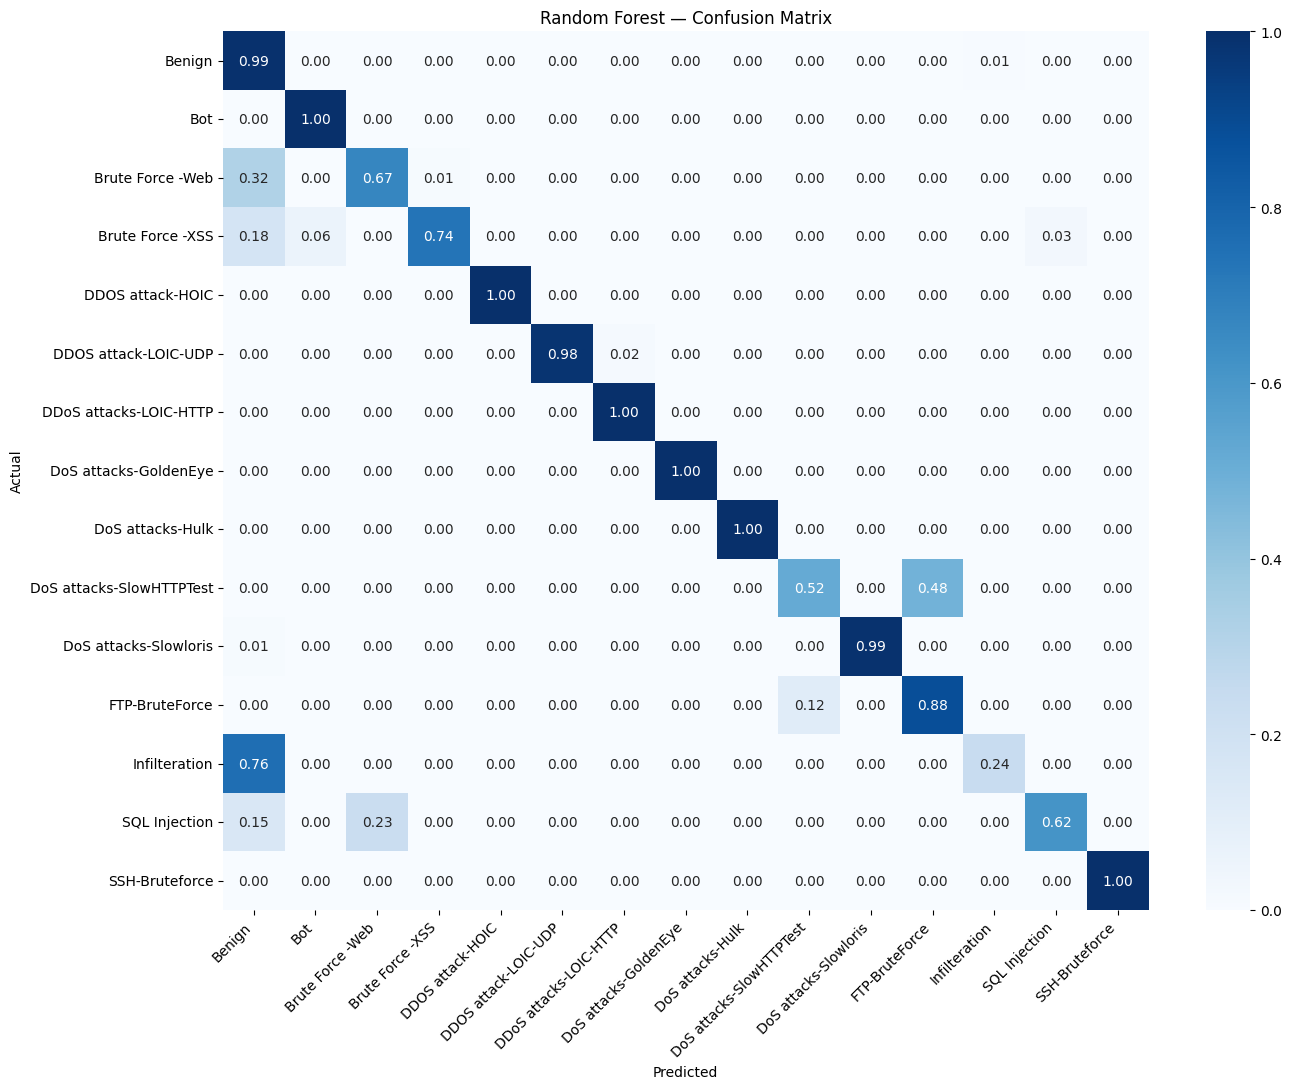

Saved: rf_confusion_matrix.png


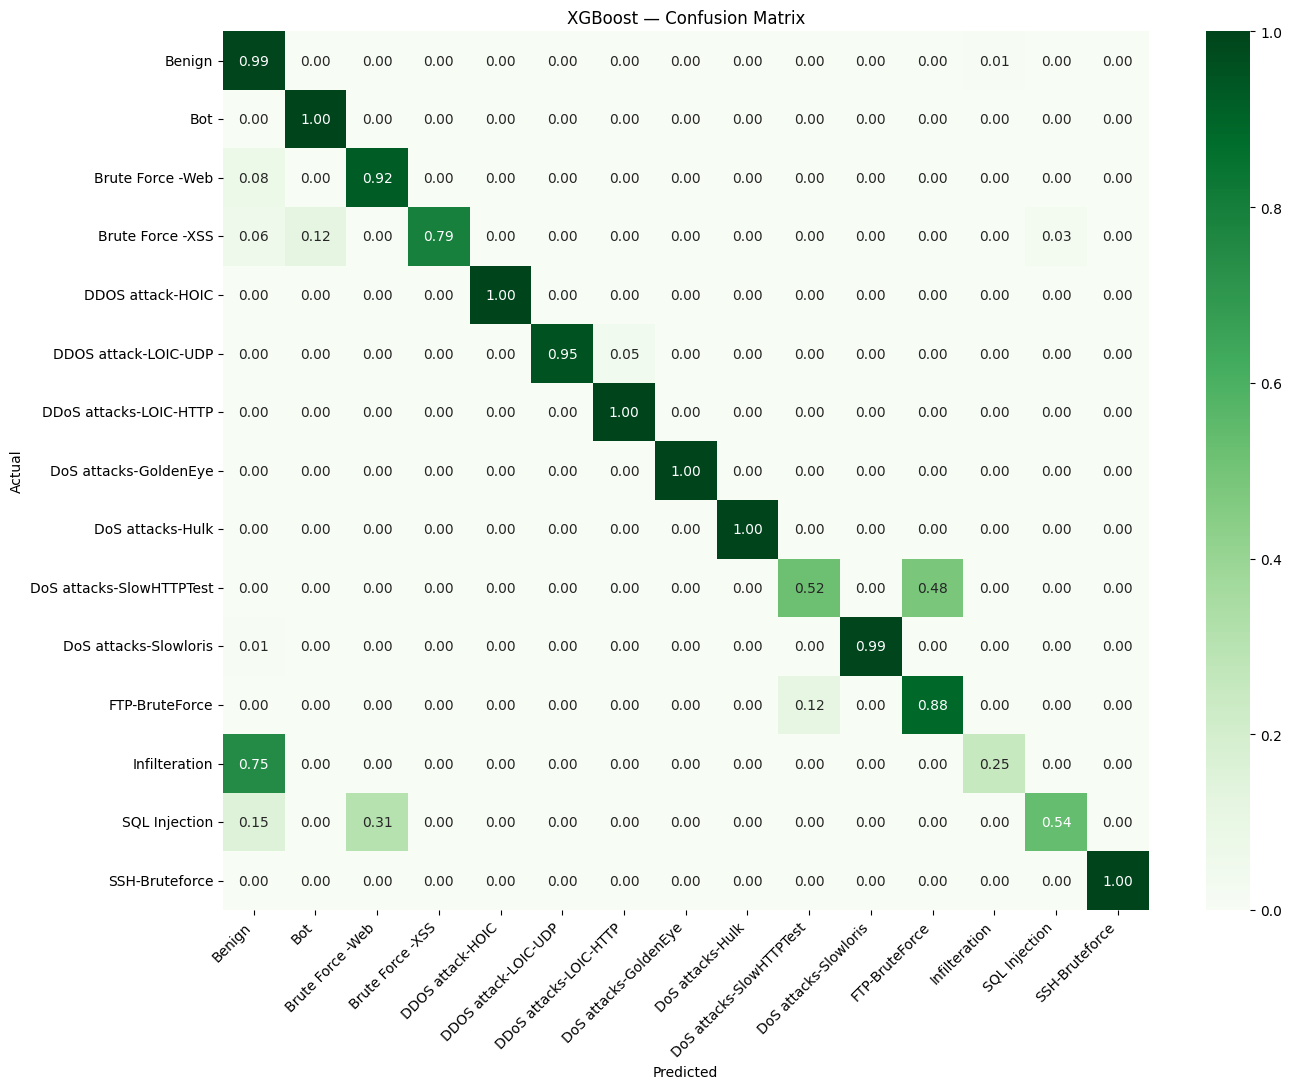

Saved: xgb_confusion_matrix.png


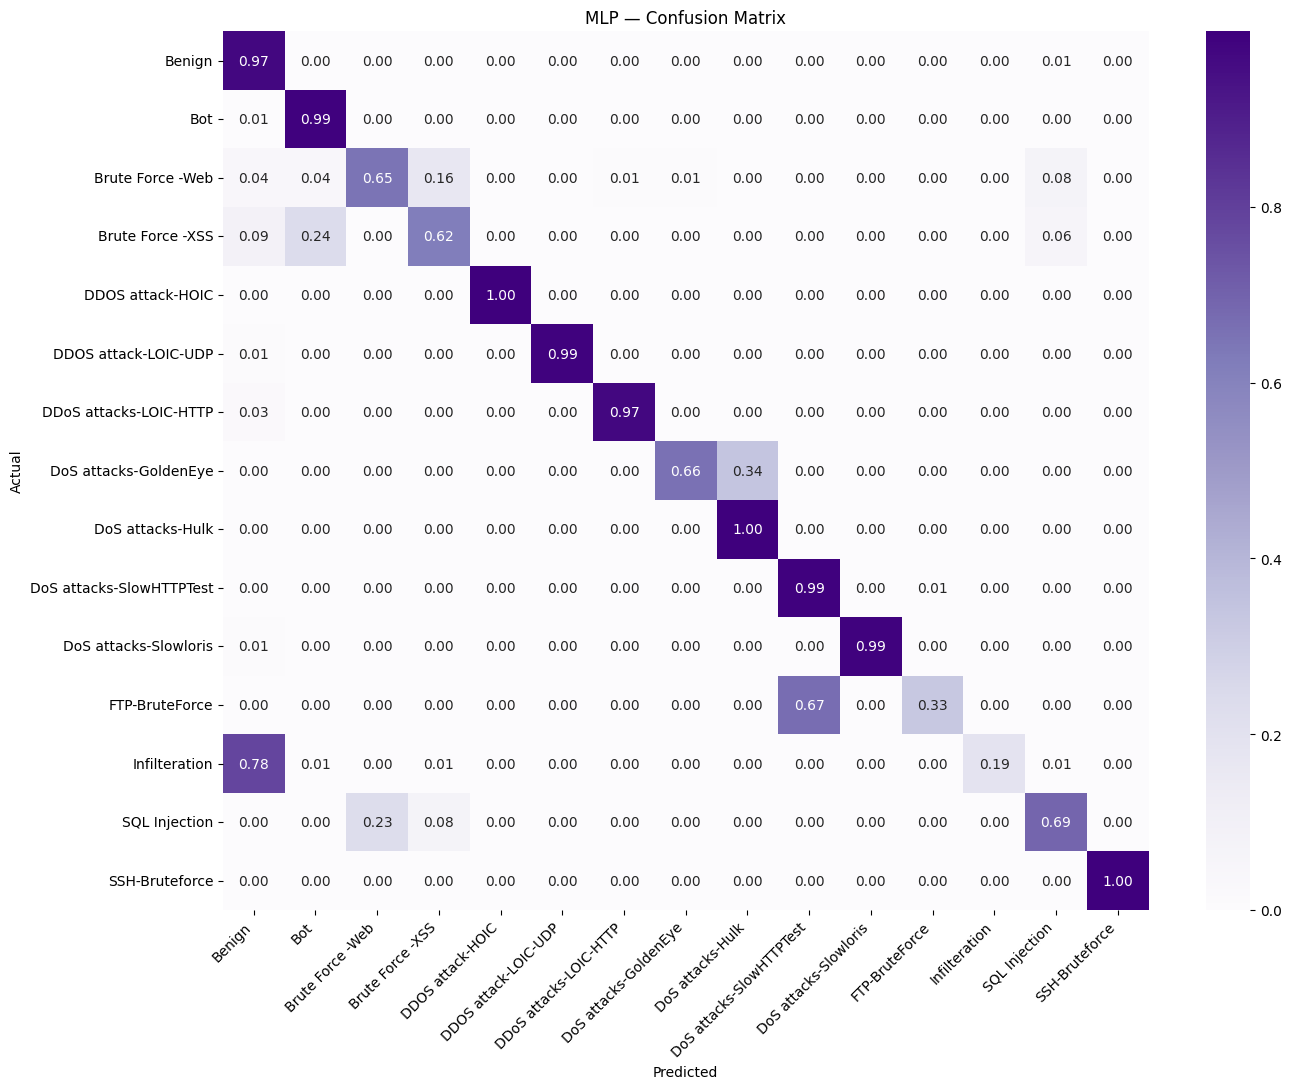

Saved: mlp_confusion_matrix.png


In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Normalised confusion matrices
#
# Plots a row-normalised confusion matrix for each model.
# Row normalisation (normalize='true') shows recall per class — each
# row sums to 1, so the diagonal shows the fraction of each true class
# correctly identified. This is the natural view for IDS evaluation
# because missed attacks (low diagonal recall) are more critical than
# false alarms. Saved as PNG files to results/.
# ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

os.makedirs('results', exist_ok=True)

def plot_confusion_matrix(y_true, y_pred, title, filename, cmap):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt='.2f',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cmap=cmap)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'results/{filename}')
    plt.show()
    print(f"Saved: {filename}")

plot_confusion_matrix(y_test, y_pred_rf,
    'Random Forest — Confusion Matrix', 'rf_confusion_matrix.png', 'Blues')

plot_confusion_matrix(y_test, y_pred_xgb,
    'XGBoost — Confusion Matrix', 'xgb_confusion_matrix.png', 'Greens')

plot_confusion_matrix(y_test, y_pred_mlp,
    'MLP — Confusion Matrix', 'mlp_confusion_matrix.png', 'Purples')

In [10]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 — Model comparison summary table
#
# Computes overall accuracy, macro-averaged precision/recall/F1, and
# weighted F1 for each supervised model.
# Macro averages treat all 15 classes equally regardless of size —
# this is the right metric for IDS where minority attack classes matter.
# Weighted F1 weights each class by its support and reflects overall
# system accuracy on the real (Benign-dominated) distribution.
# Results are stored in the 'results' dict (initialised in cell 5)
# for export to CSV in cell 12.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb,
    'MLP':           y_pred_mlp,
}

print('=' * 82)
print(f"{'Model':<20} {'Accuracy':>10} {'Macro-P':>8} {'Macro-R':>8} {'Macro-F1':>9} {'Wtd-F1':>8}")
print('=' * 82)
for name, y_pred in models.items():
    acc   = accuracy_score(y_test, y_pred)
    mp    = precision_score(y_test, y_pred, average='macro',    zero_division=0)
    mr    = recall_score(   y_test, y_pred, average='macro',    zero_division=0)
    mf1   = f1_score(       y_test, y_pred, average='macro',    zero_division=0)
    wf1   = f1_score(       y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'Accuracy': acc, 'Macro-Precision': mp, 'Macro-Recall': mr,
                     'Macro-F1': mf1, 'Weighted-F1': wf1}
    print(f'{name:<20} {acc:>10.4f} {mp:>8.4f} {mr:>8.4f} {mf1:>9.4f} {wf1:>8.4f}')
print('=' * 82)

Model                  Accuracy  Macro-P  Macro-R  Macro-F1   Wtd-F1


Random Forest            0.9815   0.8384   0.8417    0.8360   0.9804
XGBoost                  0.9820   0.7717   0.8564    0.7850   0.9808
MLP                      0.9608   0.6480   0.8030    0.6381   0.9627


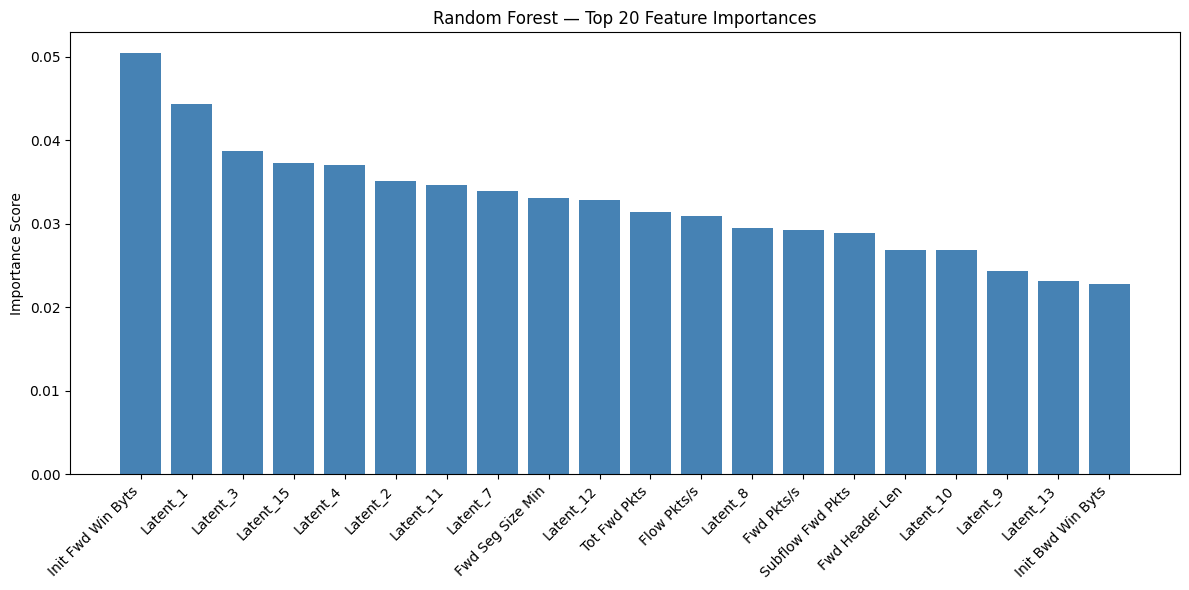

Feature importance plot saved!


In [11]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 — Random Forest feature importance
#
# Plots the top 20 features ranked by mean decrease in impurity (MDI)
# from the trained Random Forest.
# Feature names are resolved by reconstructing the 77-column preprocessed
# space: load all raw CSV headers, drop the 6 identifier columns that
# preprocessing removes, then index by selected_indices.
# importances_rf was extracted from the in-process Random Forest and
# saved to results/ in Cell 2 (importances_rf.npy).
# ─────────────────────────────────────────────────────────────────────
import glob, pandas as pd

selected_indices = np.load('models/selected_indices.npy')

_COLS_TO_DROP   = {'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Timestamp', 'Label'}
# Prefer the canonical feature order saved by preprocessing.ipynb; fall back to
# reconstructing it from raw headers (deduped on stripped names so inconsistent
# header whitespace across files cannot silently misalign selected_indices).
import json as _json, os as _os
_canonical = 'models/feature_cols.json'
if _os.path.exists(_canonical):
    with open(_canonical) as _fh:
        _feature_cols = _json.load(_fh)
else:
    _raw_csvs = sorted(glob.glob('data/raw/*.csv'))
    if not _raw_csvs:
        raise FileNotFoundError(
            'Need models/feature_cols.json or data/raw/*.csv to resolve feature names.')
    _seen, _feature_cols = set(), []
    for _f in _raw_csvs:
        for _c in pd.read_csv(_f, nrows=0).columns:
            _cs = _c.strip()
            if _cs in _COLS_TO_DROP or _cs in _seen:
                continue
            _seen.add(_cs); _feature_cols.append(_cs)
handcrafted_names = [_feature_cols[i] for i in selected_indices]
latent_names      = [f'Latent_{i}' for i in range(16)]
all_feature_names = handcrafted_names + latent_names

top20_idx = np.argsort(importances_rf)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances_rf[top20_idx], color='steelblue')
plt.xticks(range(20), [all_feature_names[i] for i in top20_idx], rotation=45, ha='right')
plt.title('Random Forest — Top 20 Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('results/feature_importance.png')
plt.show()
print('Feature importance plot saved!')

In [12]:
# ─────────────────────────────────────────────────────────────────────
# CELL 10 — Anomaly detection evaluation (Isolation Forest + AE)
#
# Evaluates both anomaly detectors as binary classifiers (benign vs attack).
# Key metrics:
#   Recall    — fraction of actual attacks flagged (TP / total attacks)
#   FPR       — fraction of benign samples wrongly flagged (FP / total benign)
#   Precision — fraction of flagged samples that are genuine attacks
#               (TP / total flagged)
# A useful IDS detector needs high recall and low FPR simultaneously.
# Both detectors are added to the 'results' dict for CSV export.
# ─────────────────────────────────────────────────────────────────────
attack_mask   = (y_test != 0)
benign_mask   = ~attack_mask
total_attacks = int(attack_mask.sum())
total_benign  = int(benign_mask.sum())
total         = len(y_test)

def eval_anomaly(flags, name):
    flagged        = int(flags.sum())
    attacks_caught = int(((flags == 1) & attack_mask).sum())   # TP
    benign_flagged = int(((flags == 1) & benign_mask).sum())   # FP
    recall    = attacks_caught / total_attacks if total_attacks else 0
    fpr       = benign_flagged / total_benign  if total_benign  else 0
    precision = attacks_caught / flagged       if flagged       else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) else 0)

    print(f'{"=" * 45}')
    print(f'{name} — ANOMALY DETECTION')
    print(f'{"=" * 45}')
    print(f'Total test samples : {total:>10,}')
    print(f'Flagged as anomaly : {flagged:>10,}  ({flagged/total*100:.2f}%)')
    print(f'Flagged as normal  : {total - flagged:>10,}  ({(total - flagged)/total*100:.2f}%)')
    print()
    print(f'Total attacks      : {total_attacks:>10,}')
    print(f'Attacks caught (TP): {attacks_caught:>10,}  recall    = {recall:.4f}')
    print(f'Benign flagged (FP): {benign_flagged:>10,}  FPR       = {fpr:.4f}')
    print(f'Precision (TP/flag): {attacks_caught:>10,}/{flagged:<10,} precision = {precision:.4f}')
    print(f'Binary F1          :             {f1:.4f}')
    print()
    # Anomaly detectors are binary-only; report under Binary-* keys so the
    # exported CSV never mixes binary numbers into the macro/weighted columns.
    return {'Binary-Precision': precision, 'Binary-Recall': recall, 'Binary-F1': f1}

results['Isolation Forest']   = eval_anomaly(anomaly_flags,    'ISOLATION FOREST')
results['AE Anomaly Detector'] = eval_anomaly(anomaly_flags_ae, 'AUTOENCODER ANOMALY DETECTOR')

ISOLATION FOREST — ANOMALY DETECTION
Total test samples :  2,434,942
Flagged as anomaly :    424,846  (17.45%)
Flagged as normal  :  2,010,096  (82.55%)

Total attacks      :    412,235
Attacks caught (TP):     82,698  recall    = 0.2006
Benign flagged (FP):    342,148  FPR       = 0.1692
Precision (TP/flag):     82,698/424,846    precision = 0.1947
Binary F1          :             0.1976

AUTOENCODER ANOMALY DETECTOR — ANOMALY DETECTION
Total test samples :  2,434,942
Flagged as anomaly :    803,896  (33.01%)
Flagged as normal  :  1,631,046  (66.99%)

Total attacks      :    412,235
Attacks caught (TP):    371,071  recall    = 0.9001
Benign flagged (FP):    432,825  FPR       = 0.2140
Precision (TP/flag):    371,071/803,896    precision = 0.4616
Binary F1          :             0.6102



In [13]:
# ─────────────────────────────────────────────────────────────────────
# CELL 11 — Binary attack-vs-benign comparison across all five models
#
# Collapses the 15-class supervised predictions to binary
# (0 = Benign, 1 = any attack) so all five models can be compared on
# the same task. This is the standard IDS binary detection framing.
# FPR (false positive rate on Benign) is critical for operational use:
# a high FPR means too many legitimate connections are blocked or alerted,
# making the system unusable in practice regardless of attack recall.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

y_binary = (y_test != 0).astype(int)  # ground truth: 0=Benign, 1=Attack

binary_preds = {
    'Random Forest'        : (y_pred_rf  != 0).astype(int),
    'XGBoost'              : (y_pred_xgb != 0).astype(int),
    'MLP'                  : (y_pred_mlp != 0).astype(int),
    'Isolation Forest'     : anomaly_flags,
    'AE Anomaly Detector'  : anomaly_flags_ae,
}

print('=' * 78)
print(f"{'Model':<24} {'Precision':>10} {'Recall':>8} {'F1':>8} {'FPR (Benign→Attack)':>22}")
print('=' * 78)
for name, y_bin_pred in binary_preds.items():
    p   = precision_score(y_binary, y_bin_pred, zero_division=0)
    r   = recall_score(   y_binary, y_bin_pred, zero_division=0)
    f1  = f1_score(       y_binary, y_bin_pred, zero_division=0)
    fp  = int(((y_bin_pred == 1) & (y_binary == 0)).sum())
    tn_fp = int((y_binary == 0).sum())
    fpr = fp / tn_fp if tn_fp else 0
    print(f'{name:<24} {p:>10.4f} {r:>8.4f} {f1:>8.4f} {fpr:>22.4f}')
print('=' * 78)

Model                     Precision   Recall       F1    FPR (Benign→Attack)


Random Forest                0.9686   0.9549   0.9617                 0.0063
XGBoost                      0.9705   0.9556   0.9630                 0.0059
MLP                          0.8842   0.9476   0.9148                 0.0253
Isolation Forest             0.1947   0.2006   0.1976                 0.1692
AE Anomaly Detector          0.4616   0.9001   0.6102                 0.2140


In [14]:
# ─────────────────────────────────────────────────────────────────────
# CELL 12 — Export final results to CSV
#
# Saves the model comparison table (accuracy, macro/weighted metrics)
# to results/model_comparison.csv for reporting.
# Supervised models report multiclass macro/weighted metrics; the two
# anomaly detectors are binary-only. Each number therefore sits under a
# header matching how it was computed (Macro-*/Weighted-F1 for the
# supervised rows, Binary-* for the detectors); the non-applicable
# columns are NaN for each row.
# ─────────────────────────────────────────────────────────────────────
import pandas as pd

results_df = pd.DataFrame(results).T
results_df.to_csv(f'{RESULTS}/model_comparison.csv')
print('Results saved to model_comparison.csv')
print()
print(results_df.round(4).to_string())


Results saved to model_comparison.csv

                     Accuracy  Macro-Precision  Macro-Recall  Macro-F1  Weighted-F1  Binary-Precision  Binary-Recall  Binary-F1
Random Forest          0.9815           0.8384        0.8417    0.8360       0.9804               NaN            NaN        NaN
XGBoost                0.9820           0.7717        0.8564    0.7850       0.9808               NaN            NaN        NaN
MLP                    0.9608           0.6480        0.8030    0.6381       0.9627               NaN            NaN        NaN
Isolation Forest          NaN              NaN           NaN       NaN          NaN            0.1947         0.2006     0.1976
AE Anomaly Detector       NaN              NaN           NaN       NaN          NaN            0.4616         0.9001     0.6102


=== RF + XGB Soft-Vote Ensemble (w(RF)=0.80) ===
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99   2022707
                     Bot       0.99      1.00      0.99     42929
        Brute Force -Web       0.70      0.67      0.69        91
        Brute Force -XSS       0.70      0.76      0.73        34
        DDOS attack-HOIC       1.00      1.00      1.00    102902
    DDOS attack-LOIC-UDP       0.74      0.99      0.85       259
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     86429
   DoS attacks-GoldenEye       1.00      1.00      1.00      6226
        DoS attacks-Hulk       1.00      1.00      1.00     69287
DoS attacks-SlowHTTPTest       0.76      0.52      0.62     20984
   DoS attacks-Slowloris       0.92      0.99      0.96      1648
          FTP-BruteForce       0.72      0.88      0.79     29004
           Infilteration       0.32      0.25      0.28     24290
           SQL Injection  

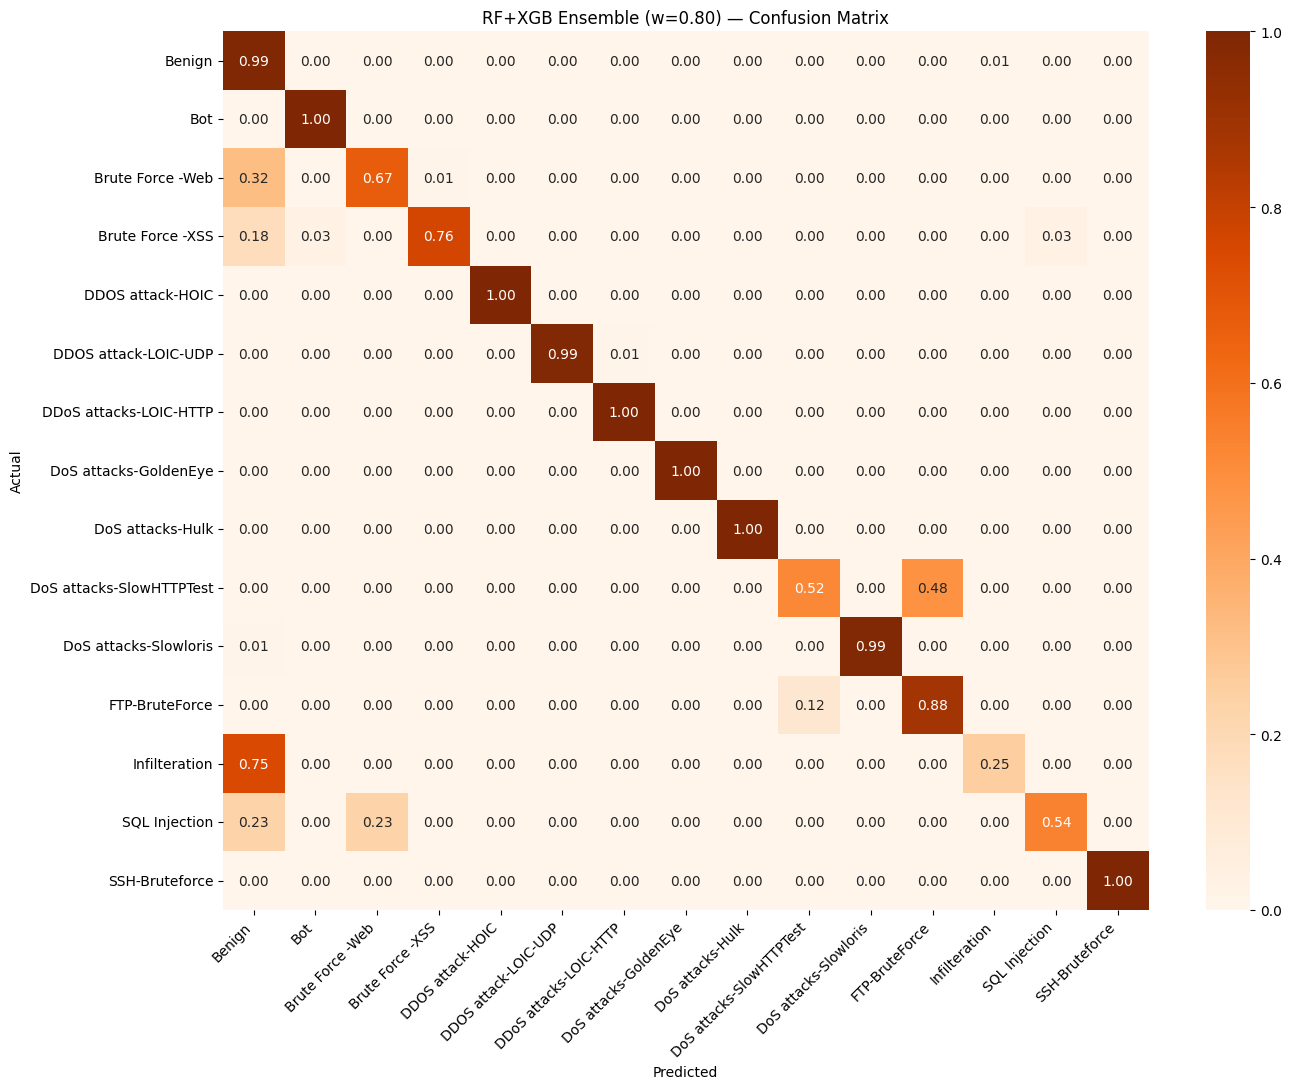

In [15]:
# ─────────────────────────────────────────────────────────────────────
# CELL 13 — RF + XGB Soft-Vote Ensemble (validation-tuned blend weight)
#
# Blends the raw class probabilities from RF and XGB as
#     p = w * p_RF + (1 - w) * p_XGB
# using the weight w and per-class thresholds that were tuned on the
# validation set in model_training.ipynb (CELL 16) — NOT a hardcoded 0.5.
# Both are loaded from disk so this matches the ensemble reported during
# training (w(RF) = 0.80). Predictions are saved to y_pred_ensemble.npy
# for the cost and comparison cells.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

if proba_rf is None or proba_xgb is None:
    raise RuntimeError("proba_rf / proba_xgb not loaded — re-run Cells 2 and 3 first.")

# Validation-tuned blend weight and calibrated thresholds (model_training.ipynb CELL 16)
WEIGHT              = float(np.load(f'{MODELS}/ensemble_weight.npy')[0])
ensemble_thresholds = np.load(f'{MODELS}/thresholds_ensemble.npy')
ensemble_proba      = WEIGHT * proba_rf + (1 - WEIGHT) * proba_xgb
y_pred_ensemble     = predict_calibrated(ensemble_proba, ensemble_thresholds)
np.save(f'{RESULTS}/y_pred_ensemble.npy', y_pred_ensemble)

print(f'=== RF + XGB Soft-Vote Ensemble (w(RF)={WEIGHT:.2f}) ===')
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_, zero_division=0))

mf1_rf       = f1_score(y_test, y_pred_rf,      average='macro', zero_division=0)
mf1_xgb      = f1_score(y_test, y_pred_xgb,     average='macro', zero_division=0)
mf1_ensemble = f1_score(y_test, y_pred_ensemble, average='macro', zero_division=0)
best_solo    = max(mf1_rf, mf1_xgb)

print(f'Macro-F1:')
print(f'  RF alone  : {mf1_rf:.4f}')
print(f'  XGB alone : {mf1_xgb:.4f}')
print(f'  Ensemble  : {mf1_ensemble:.4f}  ' +
      ('▲ improved' if mf1_ensemble > best_solo else f'▼ vs best solo ({best_solo:.4f})'))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_ensemble, normalize='true')
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='.2f',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Oranges')
plt.title(f'RF+XGB Ensemble (w={WEIGHT:.2f}) — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS}/ensemble_confusion_matrix.png', dpi=150)
plt.show()


In [16]:
# ─────────────────────────────────────────────────────────────────────
# CELL 14 — Inference Latency Benchmark
#
# Measures per-sample inference time for each model on a 10,000-row
# random subsample of the test set (averaged over 10 repeated runs).
# All three models are timed the SAME way on the SAME subsample, so the
# numbers are directly comparable. The Random Forest is still resident
# from Cell 2; if the kernel was restarted it is reloaded from disk
# (~11 GB, fits in the recommended 64 GB box). MLP runs on the selected
# device (CPU here), so its throughput reflects that.
#
# NOTE: this is small-batch (10k) per-sample latency including per-call
# overhead — the natural metric for an online IDS. It is not the same as
# the bulk throughput seen in Cell 2, where RF scored the full 2.4M-row
# test set in one call.
# ─────────────────────────────────────────────────────────────────────
import time, gc

BENCH_N = 10_000
N_RUNS  = 10
rng = np.random.default_rng(42)
bench_idx = rng.choice(len(X_test), size=BENCH_N, replace=False)
X_bench   = np.array(X_test[bench_idx], dtype=np.float32)  # materialise mmap

latency = {}

# ── MLP ──────────────────────────────────────────────────────────
print('Benchmarking MLP...')
mlp_b = MLP(56, len(le.classes_)).to(device)
mlp_b.load_state_dict(torch.load(f'{MODELS}/mlp.pth', weights_only=True))
mlp_b.eval()
X_bench_t = torch.from_numpy(X_bench).to(device)
with torch.no_grad(): _ = mlp_b(X_bench_t)          # warm-up
t0 = time.perf_counter()
for _ in range(N_RUNS):
    with torch.no_grad(): _ = torch.argmax(mlp_b(X_bench_t), dim=1)
mlp_ms = (time.perf_counter() - t0) / N_RUNS / BENCH_N * 1000
latency['MLP'] = mlp_ms
del mlp_b, X_bench_t; gc.collect()
print(f'  MLP  : {mlp_ms:.4f} ms/sample  ({int(1000/mlp_ms):,} samples/sec)')

# ── XGBoost ──────────────────────────────────────────────────────
print('Benchmarking XGBoost...')
import xgboost as xgb
xgb_b = joblib.load(f'{MODELS}/xgboost.pkl')
_ = xgb_b.predict_proba(X_bench[:100])              # warm-up
t0 = time.perf_counter()
for _ in range(N_RUNS): _ = xgb_b.predict_proba(X_bench)
xgb_ms = (time.perf_counter() - t0) / N_RUNS / BENCH_N * 1000
latency['XGBoost'] = xgb_ms
del xgb_b; gc.collect()
print(f'  XGB  : {xgb_ms:.4f} ms/sample  ({int(1000/xgb_ms):,} samples/sec)')

# ── Random Forest (in-process, same subsample) ───────────────────
# The RF object from Cell 2 is reused; if the kernel was restarted it is
# reloaded from disk. Timed identically to XGB/MLP for a fair comparison.
print('Benchmarking Random Forest...')
try:
    rf
except NameError:
    rf = joblib.load(f'{MODELS}/random_forest.pkl')
_ = rf.predict_proba(X_bench[:100])                 # warm-up
t0 = time.perf_counter()
for _ in range(N_RUNS): _ = rf.predict_proba(X_bench)
rf_ms = (time.perf_counter() - t0) / N_RUNS / BENCH_N * 1000
latency['Random Forest'] = rf_ms
print(f'  RF   : {rf_ms:.4f} ms/sample  ({int(1000/rf_ms):,} samples/sec)')

print()
print('=' * 56)
print(f"  {'Model':<26} {'ms/sample':>10} {'samples/sec':>14}")
print('=' * 56)
for name, ms in latency.items():
    print(f"  {name:<26} {ms:>10.4f} {int(1000/ms):>14,}")
print('=' * 56)

Benchmarking MLP...
  MLP  : 0.0075 ms/sample  (133,154 samples/sec)
Benchmarking XGBoost...


/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [00:00:14] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [00:00:14] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [00:00:14] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


  XGB  : 0.2352 ms/sample  (4,251 samples/sec)
Benchmarking Random Forest...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      |

  RF   : 0.0164 ms/sample  (61,024 samples/sec)

  Model                       ms/sample    samples/sec
  MLP                            0.0075        133,154
  XGBoost                        0.2352          4,251
  Random Forest                  0.0164         61,024


[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.2s finished


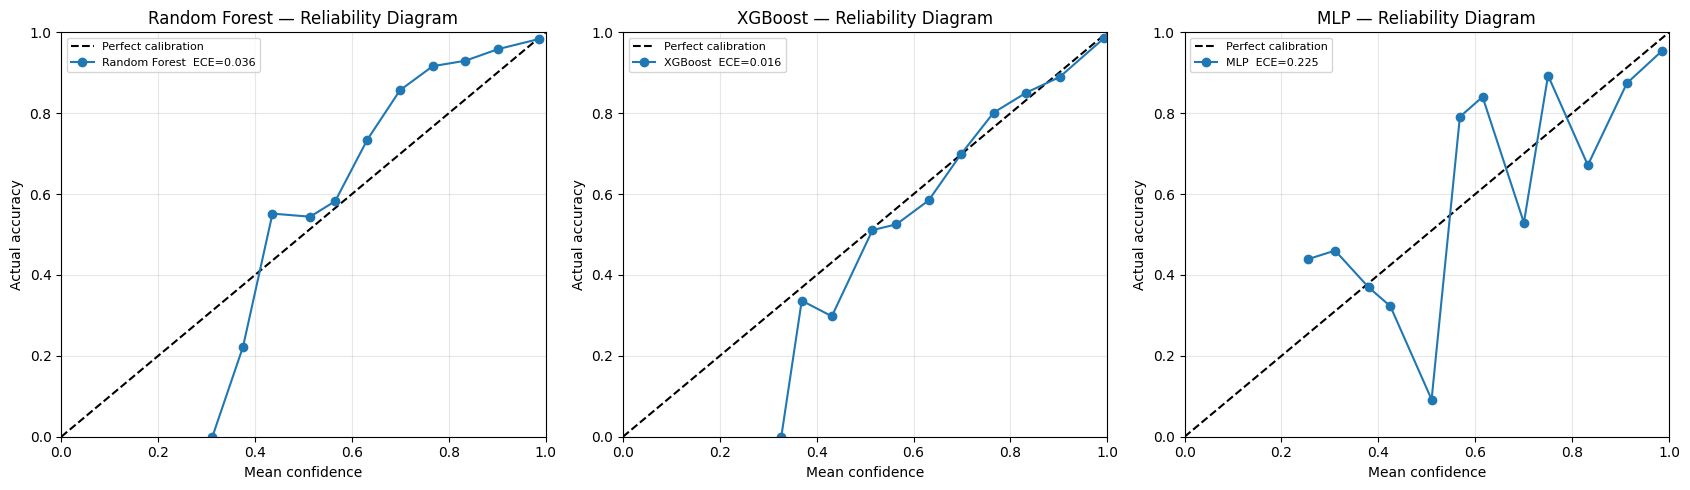

ECE:  RF=0.0363  XGB=0.0163  MLP=0.2254
ECE > 0.05 suggests Platt scaling or isotonic regression could help.
▲ MLP ECE is notable — threshold calibration partially addresses this but
  probability-level calibration (isotonic regression) could improve it further.


In [17]:
# ─────────────────────────────────────────────────────────────────────
# CELL 15 — Calibration Reliability Diagrams
#
# A reliability diagram bins predictions by the model's maximum
# class confidence and plots mean confidence vs actual accuracy per bin.
# A perfectly calibrated model follows the diagonal (confidence = accuracy).
# Expected Calibration Error (ECE) summarises the deviation in one number;
# lower is better. Overconfident models lie below the diagonal; under-
# confident models lie above it.
# ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

if proba_rf is None:
    print('Skipping — probability arrays not loaded. Re-run Cells 1, 2, 3 first.')
else:
    def reliability_diagram(proba, y_true, model_name, ax, n_bins=15):
        confidence = proba.max(axis=1)
        pred_cls   = proba.argmax(axis=1)
        correct    = (pred_cls == y_true).astype(float)
        bins       = np.linspace(0, 1, n_bins + 1)
        accs, confs, counts = [], [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (confidence >= lo) & (confidence < hi)
            if mask.sum() > 0:
                accs.append(correct[mask].mean())
                confs.append(confidence[mask].mean())
                counts.append(mask.sum())
            else:
                accs.append(np.nan); confs.append((lo+hi)/2); counts.append(0)
        accs, confs, counts = map(np.array, [accs, confs, counts])
        ece = float(np.nansum(counts / len(y_true) * np.abs(accs - confs)))
        ax.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect calibration')
        ax.plot(confs, accs, 'o-', label=f'{model_name}  ECE={ece:.3f}')
        ax.set_xlabel('Mean confidence'); ax.set_ylabel('Actual accuracy')
        ax.set_title(f'{model_name} — Reliability Diagram')
        ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=0.3)
        return ece

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    ece_rf  = reliability_diagram(proba_rf,  y_test, 'Random Forest', axes[0])
    ece_xgb = reliability_diagram(proba_xgb, y_test, 'XGBoost',       axes[1])
    ece_mlp = reliability_diagram(proba_mlp, y_test, 'MLP',            axes[2])
    plt.tight_layout()
    plt.savefig(f'{RESULTS}/calibration_reliability.png', dpi=150)
    plt.show()
    print(f'ECE:  RF={ece_rf:.4f}  XGB={ece_xgb:.4f}  MLP={ece_mlp:.4f}')
    print('ECE > 0.05 suggests Platt scaling or isotonic regression could help.')
    if ece_mlp > 0.05:
        print('▲ MLP ECE is notable — threshold calibration partially addresses this but')
        print('  probability-level calibration (isotonic regression) could improve it further.')


XGBoost robustness test...


/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [00:00:43] WARNING: /__w/xgboost/xgboost/src/gbm/gbtree.cc:402: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [00:00:43] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  setstate(state)
/application/miniconda/25.5.1/lib/python3.13/pickle.py:1760: UserWarning: [00:00:43] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  setstate(state)


  σ=0.00: macro-F1 = 0.7850
  σ=0.02: macro-F1 = 0.2412
  σ=0.05: macro-F1 = 0.1816
  σ=0.10: macro-F1 = 0.1391
  σ=0.20: macro-F1 = 0.1052
MLP robustness test...
  σ=0.00: macro-F1 = 0.6381
  σ=0.02: macro-F1 = 0.6198
  σ=0.05: macro-F1 = 0.5904
  σ=0.10: macro-F1 = 0.5442
  σ=0.20: macro-F1 = 0.4602


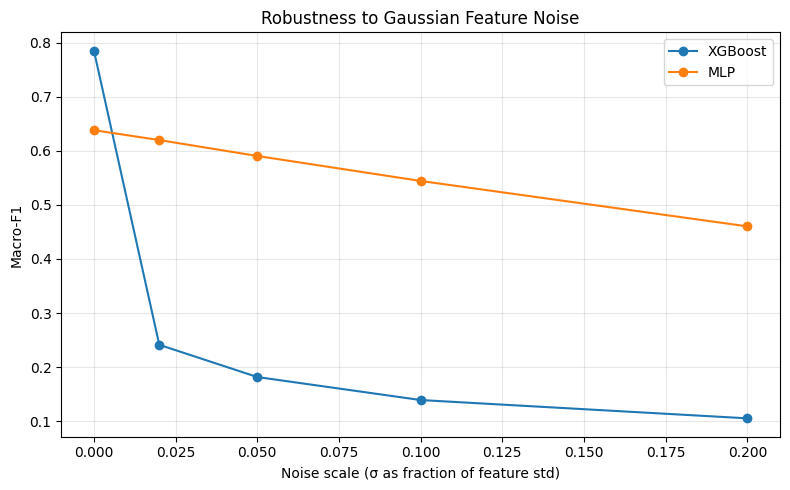

Saved: results/robustness_noise.png


In [18]:
# ─────────────────────────────────────────────────────────────────────
# CELL 16 — Robustness Test: Gaussian Feature Noise
#
# Adds zero-mean Gaussian noise scaled to each feature's standard
# deviation (σ_scale × std per feature). Sweeps σ_scale from 0 to 0.20
# to simulate sensor noise or minor distribution shift.
# XGBoost and MLP are tested in-process sequentially.
# A steeper macro-F1 drop indicates the model relies on precise feature
# values; a flatter curve indicates robustness to measurement noise.
# ─────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score

NOISE_LEVELS = [0.0, 0.02, 0.05, 0.10, 0.20]
X_test_arr   = np.asarray(X_test, dtype=np.float32)
feat_std     = X_test_arr.std(axis=0)
robustness   = {}

# ── XGBoost ──────────────────────────────────────────────────────
print('XGBoost robustness test...')
import xgboost as xgb
xgb_r = joblib.load(f'{MODELS}/xgboost.pkl')
t_xgb = np.load(f'{MODELS}/thresholds_xgb.npy')
xgb_f1s = []
for sigma in NOISE_LEVELS:
    rng = np.random.default_rng(42)
    X_noisy = X_test_arr + (rng.normal(0, 1, X_test_arr.shape) * sigma * feat_std).astype(np.float32)
    yhat    = predict_calibrated(xgb_r.predict_proba(X_noisy), t_xgb)
    f1      = f1_score(y_test, yhat, average='macro', zero_division=0)
    xgb_f1s.append(f1)
    print(f'  σ={sigma:.2f}: macro-F1 = {f1:.4f}')
robustness['XGBoost'] = xgb_f1s

# ── MLP ──────────────────────────────────────────────────────────
print('MLP robustness test...')
mlp_r = MLP(56, len(le.classes_)).to(device)
mlp_r.load_state_dict(torch.load(f'{MODELS}/mlp.pth', weights_only=True))
mlp_r.eval()
t_mlp = np.load(f'{MODELS}/thresholds_mlp.npy')
mlp_f1s = []
for sigma in NOISE_LEVELS:
    rng = np.random.default_rng(42)
    X_noisy = X_test_arr + (rng.normal(0, 1, X_test_arr.shape) * sigma * feat_std).astype(np.float32)
    with torch.no_grad():
        proba = torch.softmax(mlp_r(torch.from_numpy(X_noisy).to(device)), dim=1).cpu().numpy()
    yhat = predict_calibrated(proba, t_mlp)
    f1   = f1_score(y_test, yhat, average='macro', zero_division=0)
    mlp_f1s.append(f1)
    print(f'  σ={sigma:.2f}: macro-F1 = {f1:.4f}')
robustness['MLP'] = mlp_f1s

plt.figure(figsize=(8, 5))
for name, f1s in robustness.items():
    plt.plot(NOISE_LEVELS, f1s, 'o-', label=name)
plt.xlabel('Noise scale (σ as fraction of feature std)'); plt.ylabel('Macro-F1')
plt.title('Robustness to Gaussian Feature Noise'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS}/robustness_noise.png', dpi=150)
plt.show()
print('Saved: results/robustness_noise.png')

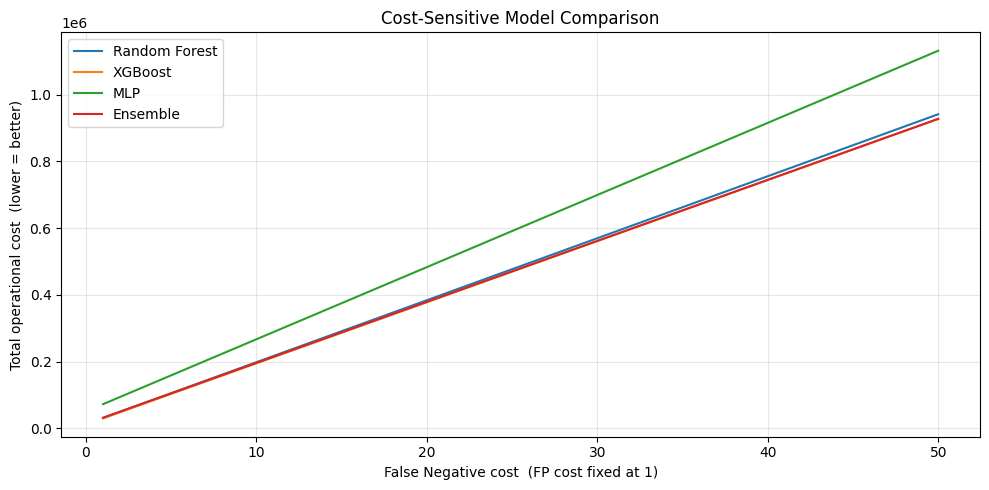

At fn_cost = 10 (missed attack costs 10× more than false alarm):
  Model                     FN (missed)  FP (false alarms)     Cost
  ──────────────────────────────────────────────────────────────────
  Random Forest                  18,577             12,750  198,520
  XGBoost                        18,313             11,989  195,119
  MLP                            21,615             51,147  267,297
  Ensemble                       18,276             13,876  196,636


In [19]:
# ─────────────────────────────────────────────────────────────────────
# CELL 17 — Cost-Sensitive Operational Analysis
#
# In IDS deployment, a missed attack (false negative) typically costs
# far more than a false alarm (false positive). This cell sweeps the
# FN penalty from 1× to 50× the FP cost and shows which model has
# the lowest total operational cost at each penalty level.
# At fn_cost=1 the models are equal-cost; as fn_cost grows the model
# with highest attack recall becomes preferred even at the cost of
# more false alarms.
# ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

y_binary = (y_test != 0).astype(int)

try:
    y_pred_ensemble
except NameError:
    y_pred_ensemble = np.load(f'{RESULTS}/y_pred_ensemble.npy')

def operational_cost(y_pred, fn_cost):
    y_bin = (y_pred != 0).astype(int)
    fn    = int(((y_binary == 1) & (y_bin == 0)).sum())
    fp    = int(((y_binary == 0) & (y_bin == 1)).sum())
    return fn * fn_cost + fp

preds = {
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb,
    'MLP':           y_pred_mlp,
    'Ensemble':      y_pred_ensemble,
}

fn_costs = np.arange(1, 51)
plt.figure(figsize=(10, 5))
for name, yp in preds.items():
    costs = [operational_cost(yp, c) for c in fn_costs]
    plt.plot(fn_costs, costs, label=name)
plt.xlabel('False Negative cost  (FP cost fixed at 1)')
plt.ylabel('Total operational cost  (lower = better)')
plt.title('Cost-Sensitive Model Comparison')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{RESULTS}/cost_sensitive.png', dpi=150)
plt.show()

print('At fn_cost = 10 (missed attack costs 10× more than false alarm):')
print(f"  {'Model':<22} {'FN (missed)':>14} {'FP (false alarms)':>18} {'Cost':>8}")
print('  ' + '─' * 66)
for name, yp in preds.items():
    y_bin = (yp != 0).astype(int)
    fn = int(((y_binary == 1) & (y_bin == 0)).sum())
    fp = int(((y_binary == 0) & (y_bin == 1)).sum())
    print(f'  {name:<22} {fn:>14,} {fp:>18,} {fn*10+fp:>8,}')


Running t-SNE on 25,890 samples  (Infilteration=24290, Benign=800, Other attacks=800)...


t-SNE complete.


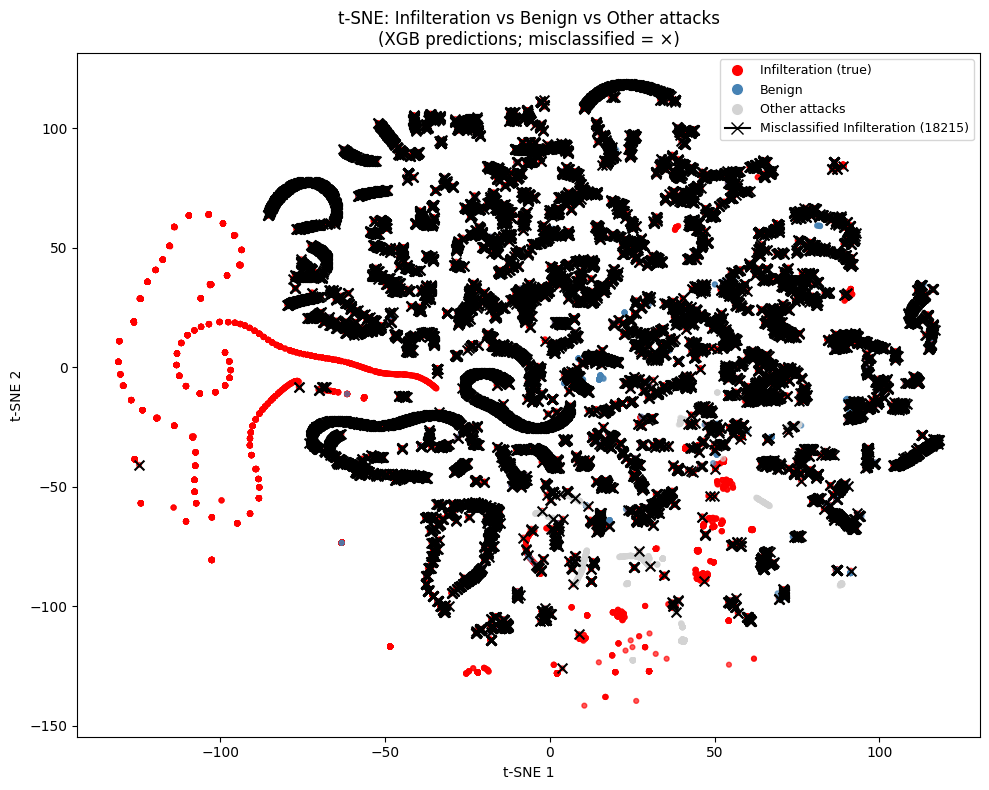


Infilteration misclassified as (XGB):
  Benign                         18208
  Bot                            6
  Brute Force -XSS               1


In [20]:
# ─────────────────────────────────────────────────────────────────────
# CELL 18 — Infilteration Class Deep-Dive: t-SNE
#
# Infilteration has the worst F1 across all models (0.25–0.30).
# This cell visualises the 56-dim feature space with t-SNE to reveal
# whether Infilteration flows are separable from Benign traffic.
# If the two clusters overlap heavily in 2-D the classification
# difficulty is inherent to the feature space, not the model.
# Misclassified Infilteration flows are highlighted with × markers.
# Runtime: ~2 min for ~2500 samples.
# ─────────────────────────────────────────────────────────────────────
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

INFIL_IDX  = list(le.classes_).index('Infilteration')
BENIGN_IDX = list(le.classes_).index('Benign')

rng        = np.random.default_rng(42)
infil_idx  = np.where(y_test == INFIL_IDX)[0]
benign_idx = rng.choice(np.where(y_test == BENIGN_IDX)[0], size=min(800, len(infil_idx)), replace=False)
other_idx  = rng.choice(np.where((y_test != INFIL_IDX) & (y_test != BENIGN_IDX))[0],
                         size=min(800, len(infil_idx)), replace=False)

sample_idx = np.concatenate([infil_idx, benign_idx, other_idx])
X_s = StandardScaler().fit_transform(np.array(X_test[sample_idx], dtype=np.float32))
y_s = y_test[sample_idx]
p_s = y_pred_xgb[sample_idx]          # XGB predictions (best single model)

print(f'Running t-SNE on {len(X_s):,} samples  (Infilteration={len(infil_idx)}, '
      f'Benign={len(benign_idx)}, Other attacks={len(other_idx)})...')
X_2d = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000).fit_transform(X_s)
print('t-SNE complete.')

colors = np.where(y_s == INFIL_IDX, 'red',
         np.where(y_s == BENIGN_IDX, 'steelblue', 'lightgrey'))
misclassified = (y_s == INFIL_IDX) & (p_s != INFIL_IDX)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_2d[:,0], X_2d[:,1], c=colors, s=12, alpha=0.65, rasterized=True)
ax.scatter(X_2d[misclassified,0], X_2d[misclassified,1],
           c='black', marker='x', s=50, linewidths=1.5, label='_')
legend = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='red',      markersize=9,label='Infilteration (true)'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue', markersize=9,label='Benign'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='lightgrey', markersize=9,label='Other attacks'),
    Line2D([0],[0],marker='x',color='black',                         markersize=9,label=f'Misclassified Infilteration ({misclassified.sum()})'),
]
ax.legend(handles=legend, fontsize=9)
ax.set_title('t-SNE: Infilteration vs Benign vs Other attacks\n(XGB predictions; misclassified = ×)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(f'{RESULTS}/infilteration_tsne.png', dpi=150)
plt.show()

print('\nInfilteration misclassified as (XGB):')
wrong = p_s[(y_s == INFIL_IDX) & (p_s != INFIL_IDX)]
for cls, cnt in zip(*np.unique(wrong, return_counts=True)):
    print(f'  {le.classes_[cls]:<30} {cnt}')


In [21]:
# ─────────────────────────────────────────────────────────────────────
# CELL 19 — Temporal Split Analysis
#
# CIC-IDS-2018 was captured over multiple days; each raw CSV file
# covers one day. The current pipeline uses a random 70/15/15 split,
# which mixes rows from all days in every partition. This can inflate
# performance if the model sees fragments of day-specific attack
# campaigns in training that then appear in the test set.
# This cell shows the class distribution per day and recommends a
# date-ordered temporal split for a more realistic evaluation.
# To actually retrain with the temporal split, update preprocessing.ipynb
# to split on file boundary rather than random row index.
# ─────────────────────────────────────────────────────────────────────
import glob, pandas as pd

raw_dir   = 'data/raw'
csv_files = sorted(glob.glob(f'{raw_dir}/*.csv'))

print(f'Found {len(csv_files)} daily CSV files.')
print('Loading label distributions per day (Label column only)...')
day_dfs = []
for f in csv_files:
    date = os.path.basename(f).replace('.csv', '')
    tmp  = pd.read_csv(f, usecols=['Label'])
    tmp['Label'] = tmp['Label'].str.strip()
    tmp['Date']  = date
    day_dfs.append(tmp)

df_all = pd.concat(day_dfs, ignore_index=True)
pivot  = df_all.groupby(['Date', 'Label']).size().unstack(fill_value=0)

print('\nSample counts per class per day:')
print(pivot.to_string())

# Show which days are attack-only vs mixed
benign_counts = pivot.get('Benign', pd.Series(0, index=pivot.index))
attack_cols   = [c for c in pivot.columns if c != 'Benign']
attack_counts = pivot[attack_cols].sum(axis=1)
print('\n  Date            Total rows    Benign       Attacks   Attack%')
print('  ' + '─' * 66)
for date in pivot.index:
    total = pivot.loc[date].sum()
    ben   = int(benign_counts.get(date, 0))
    att   = int(attack_counts.get(date, 0))
    print(f'  {date:<16} {total:>10,}  {ben:>10,}  {att:>9,}  {att/total*100:6.1f}%')

# Recommend temporal split
dates        = sorted(df_all['Date'].unique())
n_train      = int(len(dates) * 0.7)
train_dates  = dates[:n_train]
test_dates   = dates[n_train:]
print(f'\nRecommended temporal split (70/30 by day):')
print(f'  Train ({len(train_dates)} days): {train_dates}')
print(f'  Test  ({len(test_dates)} days):  {test_dates}')
print()
print('ACTION: To use temporal split, modify preprocessing.ipynb to assign')
print('rows to train/test by file date instead of random sampling.')
print('This provides a stricter eval that avoids cross-day leakage.')


Found 10 daily CSV files.
Loading label distributions per day (Label column only)...



Sample counts per class per day:
Label        Benign     Bot  Brute Force -Web  Brute Force -XSS  DDOS attack-HOIC  DDOS attack-LOIC-UDP  DDoS attacks-LOIC-HTTP  DoS attacks-GoldenEye  DoS attacks-Hulk  DoS attacks-SlowHTTPTest  DoS attacks-Slowloris  FTP-BruteForce  Infilteration  Label  SQL Injection  SSH-Bruteforce
Date                                                                                                                                                                                                                                                                                          
02-14-2018   667626       0                 0                 0                 0                     0                       0                      0                 0                         0                      0          193360              0      0              0          187589
02-15-2018   996077       0                 0                 0                 0                     0  